<a href="https://colab.research.google.com/github/SathyaPrakashD/Classical-ML-Pipeline/blob/main/sklearn_core_workout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# ============================================================
# CHECKPOINT 1 — Load & Inspect Data
# ============================================================

from sklearn.datasets import load_wine
import pandas as pd

# Step 1 — Load the dataset
data = load_wine()
#print(data.feature_names)
# Step 2 — Wrap features into a DataFrame
# Hint: data.feature_names gives you column names
df = pd.DataFrame(data.data, columns=data.feature_names)


# Step 3 — Add the target column
df['target'] = data.target

df.head(5)


# Step 4 — Print basic info
print("Shape:", df.shape)          # how many rows and columns?
print("Classes:", data.target_names)        # what are the 3 wine classes called?
print("Class counts:\n", df['target'].value_counts())

# Step 5 — Preview first 5 rows
#print(df.___)

Shape: (178, 14)
Classes: ['class_0' 'class_1' 'class_2']
Class counts:
 target
1    71
0    59
2    48
Name: count, dtype: int64


In [14]:
df.head(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [34]:
# ============================================================
# CHECKPOINT 2 — Split first, then Scale (correct order)
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1 — Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Step 2 — Split BEFORE scaling
# test_size=0.2 means 20% test, 80% train
# random_state fixes the random split so results are reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

# Step 3 — Fit scaler on TRAIN only
scaler = StandardScaler()
scaler.fit(X_train)             # learns mean & std from train only

# Step 4 — Transform both using train's stats
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Step 5 — Verify scaling worked
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("\nAFTER scaling (train set):")
print(X_train_df[['alcohol', 'magnesium', 'proline']].describe().round(2))

Train size: 142
Test size: 36

AFTER scaling (train set):
       alcohol  magnesium  proline
count   142.00     142.00   142.00
mean      0.00      -0.00    -0.00
std       1.00       1.00     1.00
min      -2.39      -2.09    -1.52
25%      -0.79      -0.84    -0.77
50%       0.04      -0.17    -0.25
75%       0.85       0.45     0.66
max       2.26       4.22     2.70


In [36]:
# Step 5 — Verify scaling worked
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [35]:
# Step 5 — Verify scaling worked
X_train_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.665293,-0.608406,1.218962,1.605400,-0.167384,0.804002,-0.691678,1.267226,1.877540,3.419473,-1.656329,-0.879409,-0.248606
1,-0.549525,2.751541,1.003315,1.605400,-0.304379,-0.785384,-1.401233,2.049600,-0.873505,-0.024801,-0.584633,-1.254621,-0.729922
2,-0.745310,-1.143541,-0.937507,-0.282704,-0.852357,1.937029,1.746791,-1.001659,0.587987,-0.240068,0.358460,0.246227,-0.248606
3,0.612948,-0.617179,1.003315,0.879206,-0.783860,0.489272,-0.901547,1.188988,1.172585,2.881305,-1.656329,-1.129550,-0.381383
4,0.111249,-0.766315,-0.937507,-1.154137,-0.167384,0.174542,0.637487,-0.688710,-0.409266,-0.584496,0.958609,0.135053,0.946386


In [40]:
# ============================================================
# CHECKPOINT 3 — Train Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression

# Step 1 — Create the model
model = LogisticRegression(max_iter=200)   # try 200 to start

# Step 2 — Train it (only on train data)
model.fit(X_train_scaled,y_train)

# Step 3 — Predict on test set
y_pred = model.predict(X_test_scaled)

# Step 4 — Score it
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))

# Step 5 — Inspect one prediction
print("\nFirst test sample — true label   :", y_test.values[0])
print("First test sample — predicted    :", y_pred[0])
print("First test sample — probabilities:", model.predict_proba(X_test_scaled)[0].round(3))

Accuracy: 1.0

First test sample — true label   : 0
First test sample — predicted    : 0
First test sample — probabilities: [0.998 0.001 0.001]


In [42]:
# ============================================================
# CHECKPOINT 4 — Cross Validation
# ============================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Step 1 — Build a pipeline (scaler + model in one object)
# This ensures scaling happens correctly inside each fold
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200))
])

# Step 2 — Run 5-fold cross validation on the FULL dataset
# Note: we use original X and y here, not the scaled versions
# The pipeline handles scaling safely inside each fold
scores = cross_val_score(pipeline, X, y, cv=5)

# Step 3 — Print results
print("Fold scores :", scores.round(4))
print("Mean accuracy:", round(scores.mean(), 4))
print("Std deviation:", round(scores.std(), 4))

Fold scores : [0.9722 0.9722 1.     0.9714 1.    ]
Mean accuracy: 0.9832
Std deviation: 0.0137


In [44]:
# ============================================================
# CHECKPOINT 5 — Random Forest vs Logistic Regression
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Step 1 — Build Random Forest pipeline
# Note: Random Forest doesn't need scaling — but we keep it
# in the pipeline anyway for consistency. It won't hurt.
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Step 2 — Cross validate Random Forest
rf_scores = cross_val_score(rf_pipeline, X, y, cv=5)

# Step 3 — Print both results side by side
print("Logistic Regression — mean: 0.9832  std: 0.0137")
print(f"Random Forest       — mean: {rf_scores.mean():.4f}  std: {rf_scores.std():.4f}")

# Step 4 — Which model wins?
if rf_scores.mean() > scores.mean():
    print("\nRandom Forest wins!")
elif rf_scores.mean() < scores.mean():
    print("\nLogistic Regression wins!")
else:
    print("\nIt's a tie!")

Logistic Regression — mean: 0.9832  std: 0.0137
Random Forest       — mean: 0.9778  std: 0.0208

Logistic Regression wins!


Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



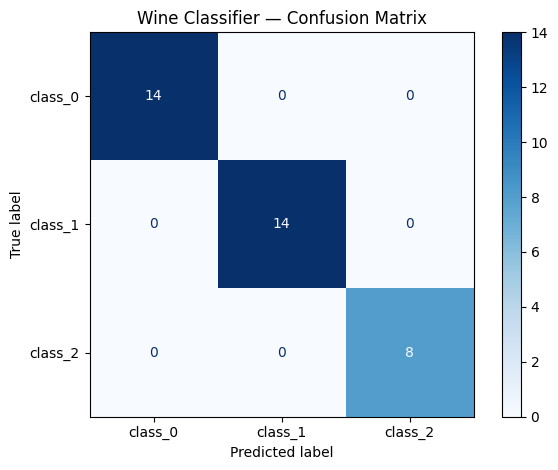

In [46]:
# ============================================================
# CHECKPOINT 6 — Full Evaluation Report
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Step 1 — Retrain Logistic Regression on train set
# (we use the winner from Checkpoint 5)
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200))
])
final_model.fit(X_train, y_train)

# Step 2 — Predict on test set
y_pred = final_model.predict(X_test)

# Step 3 — Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Step 4 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Step 5 — Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title("Wine Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()